# == Proyecto 1 Introducción al Reconocimiento de Patrones ==

## Libreta problema 2: Calidad de aire, optimización con Gridsearch y Comparación equitativa

**Luis Felipe Jiménez Ulate**/ **Carlos Eduardo Rodríguez Segura**


1. Importación de funciones del modelo y de librerías

In [21]:
from model import (
    # Implementaciones sklearn
    linear_regression_sklearn,
    random_forest_sklearn,
    optimize_random_forest_sklearn,
    # Implementaciones manuales
    linear_regression_custom,
    random_forest_custom,
    # Funciones comunes
    predecir,
    evaluar_modelo
    )
import numpy as np 

import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

2. Preprocesamiento


Generando matriz de correlación...


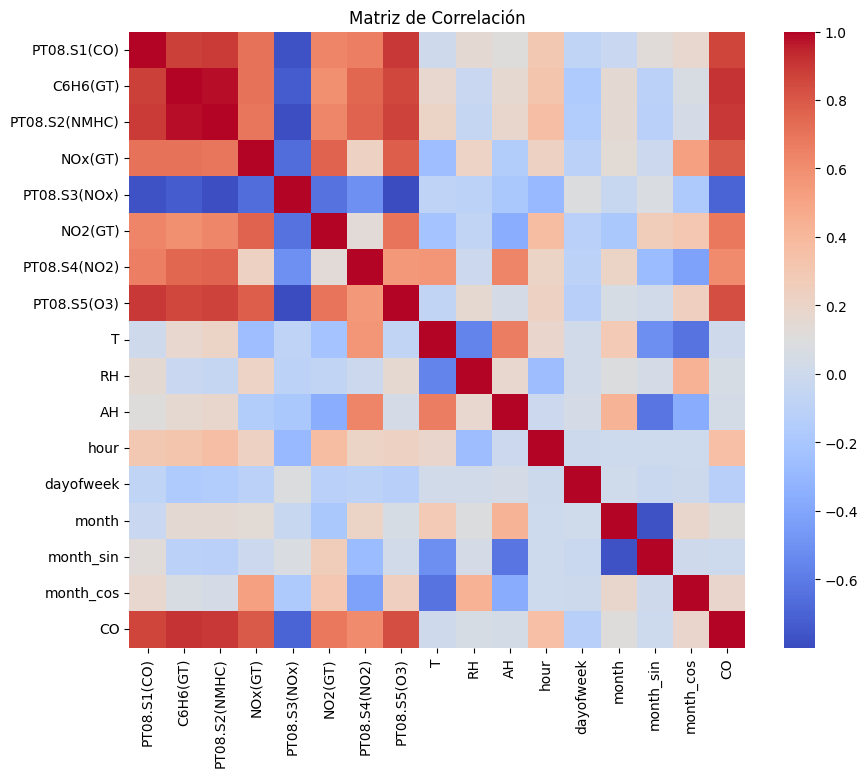


Correlaciones respecto a CO:
CO               1.000000
C6H6(GT)         0.909759
PT08.S2(NMHC)    0.895284
PT08.S1(CO)      0.862847
PT08.S5(O3)      0.837074
NOx(GT)          0.793458
NO2(GT)          0.689997
PT08.S4(NO2)     0.608329
hour             0.358159
month_cos        0.186306
month            0.111211
RH               0.057737
AH               0.034866
T                0.005197
month_sin       -0.004509
dayofweek       -0.126886
PT08.S3(NOx)    -0.695743
Name: CO, dtype: float64

Características seleccionadas (corr <= -0.2 o >= 0.2 con CO):
['PT08.S1(CO)', 'C6H6(GT)', 'PT08.S2(NMHC)', 'NOx(GT)', 'PT08.S3(NOx)', 'NO2(GT)', 'PT08.S4(NO2)', 'PT08.S5(O3)', 'hour']
CO(GT)
(0.099, 0.6]    797
(0.6, 0.9]      759
(0.9, 1.2]      814
(1.2, 1.5]      805
(1.5, 1.8]      718
(1.8, 2.2]      873
(2.2, 2.6]      676
(2.6, 3.2]      738
(3.2, 4.1]      747
(4.1, 11.9]     747
Name: count, dtype: int64
Datos preparados: 6139 muestras de entrenamiento, 1535 de prueba


In [22]:
def preparar_datos(df=None):
    # --------------------------
    # 1. Cargar dataset
    # --------------------------
    if df is None:
        DATA_PATH = os.path.join("dataset/CalidadAire.csv")
        df = pd.read_csv(DATA_PATH)

    # --------------------------
    # 2. Mostrar primeras filas completas
    # --------------------------
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", None)
    
    # --------------------------
    # 3. Eliminar columnas irrelevantes
    # --------------------------

    df = df.drop(columns=["Unnamed: 15", "Unnamed: 16"])


    # --------------------------
    # 4. Reemplazar valores nulos por NaN
    # --------------------------
    df.replace(-200, np.nan, inplace=True)
    df = df.dropna(how='all')  #totalmente vacíos
    df = df.dropna(subset=['CO(GT)']) # con valores en CO(GT) (la variable a predecir) vacíos
    #print(len(df))
    if df['NMHC(GT)'].isna().mean() > 0.8:  # Si NMHC(GT) tiene >80% NaN, se va
        df = df.drop(columns=['NMHC(GT)'])

    # --------------------------
    # 5. Cambiar formato de fecha y hora
    # --------------------------
    df['datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    df['month'] = df['datetime'].dt.month

    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

    df['datetime'] = df['datetime'].dt.date

    df = df.drop(columns=['Date', 'Time'])
    df.reset_index(drop=True, inplace=True)

    #print(df.head(-10))
    # -------------------------- 
    # # 6. Interpolar valores faltantes 
    #  -------------------------- 
    df[df.select_dtypes(include=[np.number]).columns] = \
        df.select_dtypes(include=[np.number]).interpolate(method='linear', limit_direction='both')



    
    # --------------------------
    # 7. Separar X e y
    # --------------------------

    y = df['CO(GT)']
    X = df.drop(columns=['CO(GT)', 'datetime'])

    # --------------------------
    # 8. Matriz de correlación con respecto a 'CO'
    # --------------------------
    print("\nGenerando matriz de correlación...")

    # Unir X e y temporalmente para calcular correlación
    df_corr = X.copy()
    df_corr["CO"] = y

    # Calcular matriz
    corr_matrix = df_corr.corr()

    # Mostrar heatmap cuadrado
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", square=True, cbar=True)
    plt.title("Matriz de Correlación")
    plt.show()

    # Mostrar correlaciones ordenadas respecto a CO
    print("\nCorrelaciones respecto a CO:")
    print(corr_matrix["CO"].sort_values(ascending=False))

    # --------------------------
    # 9. Eliminar columnas con baja correlación con CO
    # --------------------------
    corr_target = corr_matrix["CO"]
    cols_to_keep = corr_target[(corr_target <= -0.2) | (corr_target >= 0.2)].index.tolist()

    # Eliminar la columna CO (target)
    cols_to_keep.remove("CO")

    # Actualizar X con las columnas seleccionadas
    X = X[cols_to_keep]

    print(f"\nCaracterísticas seleccionadas (corr <= -0.2 o >= 0.2 con CO):")
    print(cols_to_keep)

    # --------------------------
    # 10. Crear bins para estratificar en regresión
    # --------------------------
    y_bins = pd.qcut(y, q=10)
    # print(bins.value_counts())
    print(y_bins.value_counts().sort_index())


    # --------------------------
    # 11. Dividir en conjunto de entrenamiento y prueba
    # --------------------------

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y_bins
    )

    # --------------------------
    # 12. Escalar variables numéricas para regresión lineal
    # --------------------------

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)


    #print(X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled)
    return X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled



X_train, X_test, y_train, y_test, X_train_scaled, X_test_scaled = preparar_datos()
print(f"Datos preparados: {X_train.shape[0]} muestras de entrenamiento, {X_test.shape[0]} de prueba")


3. Regresión Lineal

In [23]:
# Regresión Lineal propia
lr_custom = linear_regression_custom(X_train_scaled, y_train)
y_pred_lr_custom = predecir(lr_custom, X_test_scaled)

# Regresión Lineal sklearn
lr_sklearn = linear_regression_sklearn(X_train_scaled, y_train)
y_pred_lr_sklearn = predecir(lr_sklearn, X_test_scaled)


import numpy as np

# --- Funciones de métricas hechas a mano ---
def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def rmse(y, y_pred):
    return np.sqrt(mse(y, y_pred))

def r2(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

def comparar_modelos(y_true, y_pred_custom, y_pred_sklearn, nombre_modelo="Modelo"):
    """
    Compara dos implementaciones (Custom vs Sklearn) calculando métricas manualmente:
    MAE, MSE, RMSE, R²
    """
    y_true = np.array(y_true)
    y_pred_custom = np.array(y_pred_custom)
    y_pred_sklearn = np.array(y_pred_sklearn)

    

    # --- Cálculo Custom ---
    mae_custom = mae(y_true, y_pred_custom)
    mse_custom = mse(y_true, y_pred_custom)
    rmse_custom = rmse(y_true, y_pred_custom)
    r2_custom = r2(y_true, y_pred_custom)

    # --- Cálculo Sklearn ---
    mae_sklearn = mae(y_true, y_pred_sklearn)
    mse_sklearn = mse(y_true, y_pred_sklearn)
    rmse_sklearn = rmse(y_true, y_pred_sklearn)
    r2_sklearn = r2(y_true, y_pred_sklearn)

    # --- Mostrar resultados ---
    print(f"\n=== COMPARACIÓN: {nombre_modelo} ===")
    
    print("\n--- Implementación Manual ---")
    print(f"MAE:  {mae_custom:.4f}")
    print(f"MSE:  {mse_custom:.4f}")
    print(f"RMSE: {rmse_custom:.4f}")
    print(f"R²:   {r2_custom:.4f}")

    print("\n--- Implementación sklearn ---")
    print(f"MAE:  {mae_sklearn:.4f}")
    print(f"MSE:  {mse_sklearn:.4f}")
    print(f"RMSE: {rmse_sklearn:.4f}")
    print(f"R²:   {r2_sklearn:.4f}")

    print(f"\n--- Diferencia MAE entre implementaciones: {abs(mae_custom - mae_sklearn):.4f} ---")



# Comparar
comparar_modelos(y_test, y_pred_lr_custom, y_pred_lr_sklearn, "Regresión Lineal")


=== COMPARACIÓN: Regresión Lineal ===

--- Implementación Manual ---
MAE:  0.2939
MSE:  0.2081
RMSE: 0.4562
R²:   0.8993

--- Implementación sklearn ---
MAE:  0.2939
MSE:  0.2081
RMSE: 0.4562
R²:   0.8993

--- Diferencia MAE entre implementaciones: 0.0000 ---


4. Random Forest

4.1. Random Forest Optimizado

In [24]:
rf_optimized, best_params = optimize_random_forest_sklearn(X_train, y_train, random_state=42)
    
#Usar los parámetros encontrados de sklearn en la implementación manual
print(f"Parámetros optimizados: {best_params}")

rf_custom_optimized = random_forest_custom(
    X_train, y_train, 
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

print("\n Realizando predicciones")
y_pred_rf_sklearn = predecir(rf_optimized, X_test)
y_pred_rf_custom = predecir(rf_custom_optimized, X_test)




# Se comparan los resultados
comparar_modelos(y_test, y_pred_rf_custom, y_pred_rf_sklearn, "Random Forest Optimizado")

Optimizando hiperparámetros de Random Forest con GridSearchCV...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

=== MEJORES PARÁMETROS ENCONTRADOS ===
Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Mejor score CV (MSE): 0.1762
Parámetros optimizados: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Entrenando Random Forest personalizado con 200 árboles...
Árbol 1/200
Árbol 11/200
Árbol 21/200
Árbol 31/200
Árbol 41/200
Árbol 51/200
Árbol 61/200
Árbol 71/200
Árbol 81/200
Árbol 91/200
Árbol 101/200
Árbol 111/200
Árbol 121/200
Árbol 131/200
Árbol 141/200
Árbol 151/200
Árbol 161/200
Árbol 171/200
Árbol 181/200
Árbol 191/200
✓ Random Forest personalizado entrenado

 Realizando predicciones

=== COMPARACIÓN: Random Forest Optimizado ===

--- Implementación Manual ---
MAE:  0.2531
MSE:  0.1626
RMSE: 0.4032
R²:   0.9213

--- Implementación sklearn ---
MAE:  0.2333
MSE:  0.1458
RMS

4.2. Comparación con versión no optimizada

In [25]:
# Modelos
rf_default = random_forest_sklearn(X_train, y_train)
y_pred_rf_default = predecir(rf_default, X_test)

# Cálculo de métricas
mse_default = mse(y_test, y_pred_rf_default)
mse_optimized = mse(y_test, y_pred_rf_sklearn)
r2_default = r2(y_test, y_pred_rf_default)
r2_optimized = r2(y_test, y_pred_rf_sklearn)

# Comparar implementaciones (custom vs sklearn optimizado)
comparar_modelos(y_test, y_pred_rf_custom, y_pred_rf_sklearn, "Random Forest Optimizado")

# Mostrar resultados default vs optimizado
print(f"\nRandom Forest sin optimizar:")
print(f"  MAE:  {mae(y_test, y_pred_rf_default):.4f}")
print(f"  MSE:  {mse_default:.4f}")
print(f"  RMSE: {rmse(y_test, y_pred_rf_default):.4f}")
print(f"  R²:   {r2_default:.4f}")

print(f"\nRandom Forest optimizado:")
print(f"  MAE:  {mae(y_test, y_pred_rf_sklearn):.4f}")
print(f"  MSE:  {mse_optimized:.4f}")
print(f"  RMSE: {rmse(y_test, y_pred_rf_sklearn):.4f}")
print(f"  R²:   {r2_optimized:.4f}")

# Calcular mejora porcentual
mejora_mse = ((mse_default - mse_optimized) / mse_default) * 100
mejora_r2 = ((r2_optimized - r2_default) / abs(r2_default)) * 100

print(f"\nMejora con optimización:")
print(f"  MSE: {mejora_mse:+.2f}%")
print(f"  R²:  {mejora_r2:+.2f}%")



=== COMPARACIÓN: Random Forest Optimizado ===

--- Implementación Manual ---
MAE:  0.2531
MSE:  0.1626
RMSE: 0.4032
R²:   0.9213

--- Implementación sklearn ---
MAE:  0.2333
MSE:  0.1458
RMSE: 0.3819
R²:   0.9294

--- Diferencia MAE entre implementaciones: 0.0199 ---

Random Forest sin optimizar:
  MAE:  0.2350
  MSE:  0.1479
  RMSE: 0.3845
  R²:   0.9285

Random Forest optimizado:
  MAE:  0.2333
  MSE:  0.1458
  RMSE: 0.3819
  R²:   0.9294

Mejora con optimización:
  MSE: +1.37%
  R²:  +0.11%


5. Muestra de resultados de las predicciones

In [26]:
import pandas as pd

# Crear DataFrame con valores reales y predichos de cada modelo
df_predicciones = pd.DataFrame({
    "Real": y_test,
    "Random Forest Sklearn": y_pred_rf_sklearn,
    "Random Forest Custom": y_pred_rf_custom,
    "Regresión lineal Sklearn": y_pred_lr_sklearn,
    "Regresión lineal Custom": y_pred_lr_custom,
})

# Seleccionar 10 muestras aleatorias
print("\n Ejemplo de 10 predicciones vs valores reales:\n")
print(df_predicciones.sample(10, random_state=42))


 Ejemplo de 10 predicciones vs valores reales:

      Real  Random Forest Sklearn  Random Forest Custom  \
6709   3.5                 3.2315              3.297729   
4498   0.4                 0.4380              0.463837   
1285   0.8                 0.7150              0.765798   
3800   1.2                 1.2630              1.518955   
5729   3.8                 3.0620              3.321071   
1012   0.9                 0.8995              0.935867   
4825   1.4                 1.2270              1.190452   
7123   0.8                 1.8340              1.809628   
4293   1.8                 1.6880              1.721964   
4708   5.3                 5.6230              5.598398   

      Regresión lineal Sklearn  Regresión lineal Custom  
6709                  3.672852                 3.672852  
4498                  0.461678                 0.461678  
1285                  0.846402                 0.846402  
3800                  1.499303                 1.499303  
5729       

6. Comparación de resultados

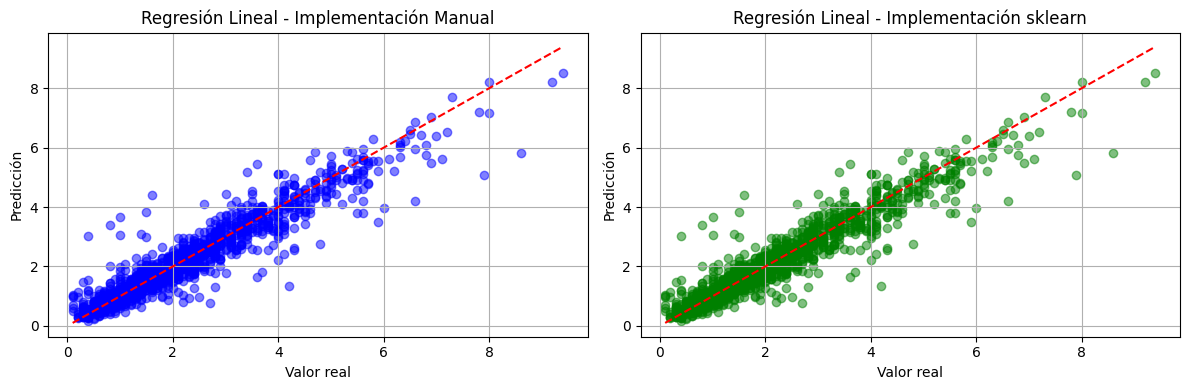

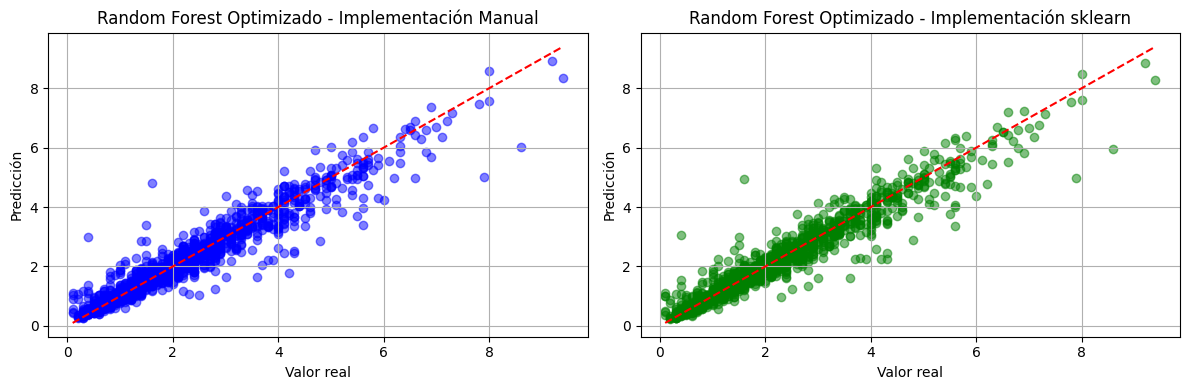

In [27]:
import matplotlib.pyplot as plt

def graficar_resultados(y_true, y_pred, nombre_modelo="Modelo"):
    plt.figure(figsize=(6, 4))
    plt.scatter(y_true, y_pred, alpha=0.5)
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    plt.xlabel("Valor real")
    plt.ylabel("Predicción")
    plt.title(f"Predicción vs Real - {nombre_modelo}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def graficar_comparacion(y_true, y_pred_custom, y_pred_sklearn, nombre_modelo="Modelo"):
    """Función para graficar comparación entre implementaciones"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Implementación manual
    ax1.scatter(y_true, y_pred_custom, alpha=0.5, color='blue')
    ax1.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax1.set_xlabel("Valor real")
    ax1.set_ylabel("Predicción")
    ax1.set_title(f"{nombre_modelo} - Implementación Manual")
    ax1.grid(True)
    
    # Implementación sklearn
    ax2.scatter(y_true, y_pred_sklearn, alpha=0.5, color='green')
    ax2.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--')
    ax2.set_xlabel("Valor real")
    ax2.set_ylabel("Predicción")
    ax2.set_title(f"{nombre_modelo} - Implementación sklearn")
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
#graficar_resultados(y_test, y_pred_lr_custom, "Regresión Lineal Propia")
graficar_comparacion(y_test, y_pred_lr_custom, y_pred_lr_sklearn, "Regresión Lineal")
#graficar_resultados(y_test, y_pred_rf_custom, "Random Forest Propia Optimizada")
graficar_comparacion(y_test, y_pred_rf_custom, y_pred_rf_sklearn, "Random Forest Optimizado")